<a href="https://colab.research.google.com/github/Aditalbqhr/Water-Quality-Classification/blob/main/LulusCepatBanget.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**import Library**

In [80]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier

**Upload Dan Load Dataset**

In [81]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('IoTPond10.csv')  # sesuaikan nama file jika beda
df.head()

Saving IoTPond10.csv to IoTPond10 (2).csv


,created_at,entry_id,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Population,Length,Weight
0,2021-06-25 15:48:59 CET,1,-127.0000,100,0.0,15.45166,0.0,0,50,13.45,27.6
1,2021-06-25 15:49:19 CET,2,-127.0000,100,0.0,15.45166,0.0,0,50,13.45,27.6
2,2021-06-25 15:50:16 CET,3,27.1250,100,0.0,6.01411,0.0,139,50,13.45,27.6
3,2021-06-25 15:51:50 CET,4,27.3125,100,0.0,6.03227,0.0,131,50,13.45,27.6
4,2021-06-25 15:52:10 CET,5,27.2500,100,0.0,6.03681,0.0,133,50,13.45,27.6


**Rename Column**

In [82]:
df.rename(columns={
    'TEMPERATURE': 'Temperature',
    'TURBIDITY': 'Turbidity',
    'DISOLVED OXYGEN': 'DO',
    'AMMONIA': 'Ammonia',
    'NITRATE': 'Nitrate'
}, inplace=True)

df.columns

Index(['created_at', 'entry_id', 'Temperature', 'Turbidity', 'DO', 'pH',
       'Ammonia', 'Nitrate', 'Population', 'Length', 'Weight'],
      dtype='object')

**Cleaning Data**

In [83]:
# =========================
# CLEANING DATA (FIX)
# =========================

# 1. Replace infinity
df = df.replace([np.inf, -np.inf], np.nan)

# 2. Pilih hanya kolom numerik
num_cols = df.select_dtypes(include=[np.number]).columns

# 3. Isi missing value hanya di kolom numerik
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# 4. Clip hanya kolom numerik (INI YANG PENTING)
df[num_cols] = df[num_cols].clip(lower=-1e6, upper=1e6)

# 5. Cek hasil
print("Cek NaN:")
print(df[num_cols].isnull().sum())

Cek NaN:
entry_id       0
Temperature    0
Turbidity      0
DO             0
pH             0
Ammonia        0
Nitrate        0
Population     0
Length         0
Weight         0
dtype: int64


**Labelling**

In [84]:
def label_kualitas(row):
    score = 0

    if 6.5 <= row['pH'] <= 8.5:
        score += 1

    if row['DO'] > 5:
        score += 1

    if 25 <= row['Temperature'] <= 30:
        score += 1

    if row['Ammonia'] < 0.5:
        score += 1

    if row['Nitrate'] < 50:
        score += 1

    if score >= 4:
        return 'Baik'
    elif score >= 2:
        return 'Sedang'
    else:
        return 'Buruk'

df['kualitas_air'] = df.apply(label_kualitas, axis=1)

df[['pH','DO','Temperature','kualitas_air']].head()

,pH,DO,Temperature,kualitas_air
0,15.45166,0.0,-127.0000,Sedang
1,15.45166,0.0,-127.0000,Sedang
2,6.01411,0.0,27.1250,Sedang
3,6.03227,0.0,27.3125,Sedang
4,6.03681,0.0,27.2500,Sedang


**Distribusi Kelas**

In [85]:
print(df['kualitas_air'].value_counts())

kualitas_air
Sedang    508
Buruk      88
Baik       24
Name: count, dtype: int64


**Pemilihan Fitur**

In [86]:
# ❗ HANYA pakai fitur yang TIDAK dipakai saat labeling
X = df[['Turbidity', 'Population', 'Length', 'Weight']]

y = df['kualitas_air']

**Encoding Label**

In [87]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

**Split Data**

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**XGBoost tanpa ADASYN**

In [89]:
model_no_adasyn = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_no_adasyn.fit(X_train, y_train)

y_pred_no = model_no_adasyn.predict(X_test)

print("=== XGBoost TANPA ADASYN ===")
print(classification_report(y_test, y_pred_no))
print(confusion_matrix(y_test, y_pred_no))

=== XGBoost TANPA ADASYN ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.94      0.88      0.91        17
           2       0.93      0.98      0.96       102

    accuracy                           0.93       124
   macro avg       0.62      0.62      0.62       124
weighted avg       0.90      0.93      0.91       124

[[  0   0   5]
 [  0  15   2]
 [  1   1 100]]


In [90]:
from imblearn.over_sampling import ADASYN
from collections import Counter

adasyn = ADASYN(n_neighbors=2, random_state=42)
X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

print("Sebelum:", Counter(y_train))
print("Sesudah:", Counter(y_train_res))

Sebelum: Counter({np.int64(2): 406, np.int64(1): 71, np.int64(0): 19})
Sesudah: Counter({np.int64(2): 406, np.int64(1): 400, np.int64(0): 399})


In [91]:
import pandas as pd

print("Sebelum ADASYN:")
print(pd.Series(y_train).value_counts())

print("\nSesudah ADASYN:")
print(pd.Series(y_train_res).value_counts())

Sebelum ADASYN:
2    406
1     71
0     19
Name: count, dtype: int64

Sesudah ADASYN:
2    406
1    400
0    399
Name: count, dtype: int64


**Model XGBoost**

In [92]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

**Evaluasi Model**

In [93]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.11      1.00      0.20         5
           1       0.41      0.88      0.56        17
           2       0.95      0.39      0.56       102

    accuracy                           0.48       124
   macro avg       0.49      0.76      0.44       124
weighted avg       0.84      0.48      0.54       124


Confusion Matrix:
[[ 5  0  0]
 [ 0 15  2]
 [40 22 40]]


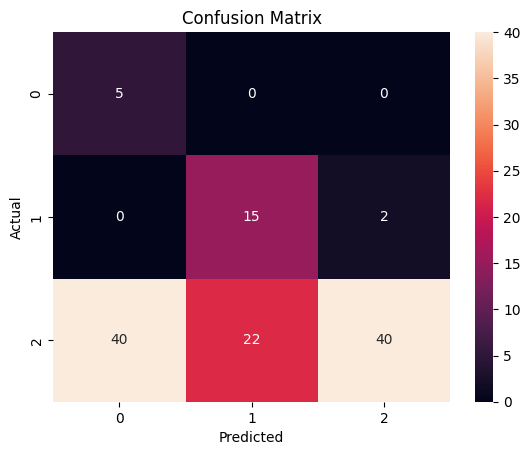

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [95]:
from sklearn.metrics import accuracy_score

print("\n=== PERBANDINGAN ===")
print("Tanpa ADASYN :", accuracy_score(y_test, y_pred_no))
print("Dengan ADASYN:", accuracy_score(y_test, y_pred))


=== PERBANDINGAN ===
Tanpa ADASYN : 0.9274193548387096
Dengan ADASYN: 0.4838709677419355


**XGBoost + ROS**

In [96]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

model_ros = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_ros.fit(X_train_ros, y_train_ros)

y_pred_ros = model_ros.predict(X_test)

print("\n=== XGBoost + ROS ===")
print(classification_report(y_test, y_pred_ros))
print(confusion_matrix(y_test, y_pred_ros))


=== XGBoost + ROS ===
              precision    recall  f1-score   support

           0       0.11      1.00      0.20         5
           1       0.79      0.88      0.83        17
           2       0.97      0.57      0.72       102

    accuracy                           0.63       124
   macro avg       0.62      0.82      0.58       124
weighted avg       0.91      0.63      0.71       124

[[ 5  0  0]
 [ 0 15  2]
 [40  4 58]]


**XGBoost + SMOTE**

In [97]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors=2, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)

print("\n=== XGBoost + SMOTE ===")
print(classification_report(y_test, y_pred_smote))
print(confusion_matrix(y_test, y_pred_smote))


=== XGBoost + SMOTE ===
              precision    recall  f1-score   support

           0       0.11      1.00      0.20         5
           1       0.83      0.88      0.86        17
           2       0.97      0.58      0.72       102

    accuracy                           0.64       124
   macro avg       0.64      0.82      0.59       124
weighted avg       0.91      0.64      0.72       124

[[ 5  0  0]
 [ 0 15  2]
 [40  3 59]]


In [98]:
from sklearn.metrics import accuracy_score

print("\n=== PERBANDINGAN AKURASI ===")
print("XGBoost           :", accuracy_score(y_test, y_pred_no))
print("XGBoost + ADASYN  :", accuracy_score(y_test, y_pred))
print("XGBoost + ROS     :", accuracy_score(y_test, y_pred_ros))
print("XGBoost + SMOTE   :", accuracy_score(y_test, y_pred_smote))


=== PERBANDINGAN AKURASI ===
XGBoost           : 0.9274193548387096
XGBoost + ADASYN  : 0.4838709677419355
XGBoost + ROS     : 0.6290322580645161
XGBoost + SMOTE   : 0.6370967741935484


**Random Forest**

In [99]:
from sklearn.ensemble import RandomForestClassifier

rf_no = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_no.fit(X_train, y_train)

y_pred_rf_no = rf_no.predict(X_test)

print("\n=== Random Forest TANPA RESAMPLING ===")
print(classification_report(y_test, y_pred_rf_no))
print(confusion_matrix(y_test, y_pred_rf_no))


=== Random Forest TANPA RESAMPLING ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.94      0.88      0.91        17
           2       0.93      0.98      0.96       102

    accuracy                           0.93       124
   macro avg       0.62      0.62      0.62       124
weighted avg       0.90      0.93      0.91       124

[[  0   0   5]
 [  0  15   2]
 [  1   1 100]]


**Random Forest + ADASYN**

In [100]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(n_neighbors=2, random_state=42)
X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

rf_adasyn = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_adasyn.fit(X_train_res, y_train_res)

y_pred_rf_adasyn = rf_adasyn.predict(X_test)

print("\n=== Random Forest + ADASYN ===")
print(classification_report(y_test, y_pred_rf_adasyn))
print(confusion_matrix(y_test, y_pred_rf_adasyn))


=== Random Forest + ADASYN ===
              precision    recall  f1-score   support

           0       0.11      1.00      0.20         5
           1       0.41      0.88      0.56        17
           2       0.95      0.39      0.56       102

    accuracy                           0.48       124
   macro avg       0.49      0.76      0.44       124
weighted avg       0.84      0.48      0.54       124

[[ 5  0  0]
 [ 0 15  2]
 [40 22 40]]


**Random Forest + ROS**

In [101]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

rf_ros = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_ros.fit(X_train_ros, y_train_ros)

y_pred_rf_ros = rf_ros.predict(X_test)

print("\n=== Random Forest + ROS ===")
print(classification_report(y_test, y_pred_rf_ros))
print(confusion_matrix(y_test, y_pred_rf_ros))


=== Random Forest + ROS ===
              precision    recall  f1-score   support

           0       0.11      1.00      0.20         5
           1       0.83      0.88      0.86        17
           2       0.97      0.58      0.72       102

    accuracy                           0.64       124
   macro avg       0.64      0.82      0.59       124
weighted avg       0.91      0.64      0.72       124

[[ 5  0  0]
 [ 0 15  2]
 [40  3 59]]


**Random Forest + SMOTE**

In [102]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors=2, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)

print("\n=== Random Forest + SMOTE ===")
print(classification_report(y_test, y_pred_rf_smote))
print(confusion_matrix(y_test, y_pred_rf_smote))


=== Random Forest + SMOTE ===
              precision    recall  f1-score   support

           0       0.11      1.00      0.20         5
           1       0.83      0.88      0.86        17
           2       0.97      0.58      0.72       102

    accuracy                           0.64       124
   macro avg       0.64      0.82      0.59       124
weighted avg       0.91      0.64      0.72       124

[[ 5  0  0]
 [ 0 15  2]
 [40  3 59]]


In [103]:
from sklearn.metrics import accuracy_score

print("\n=== PERBANDINGAN RANDOM FOREST ===")
print("RF Tanpa Resampling :", accuracy_score(y_test, y_pred_rf_no))
print("RF + ADASYN         :", accuracy_score(y_test, y_pred_rf_adasyn))
print("RF + SMOTE          :", accuracy_score(y_test, y_pred_rf_smote))
print("RF + ROS            :", accuracy_score(y_test, y_pred_rf_ros))


=== PERBANDINGAN RANDOM FOREST ===
RF Tanpa Resampling : 0.9274193548387096
RF + ADASYN         : 0.4838709677419355
RF + SMOTE          : 0.6370967741935484
RF + ROS            : 0.6370967741935484


In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("\n=== Logistic Regression TANPA RESAMPLING ===")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))


=== Logistic Regression TANPA RESAMPLING ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.00      0.00      0.00        17
           2       0.82      1.00      0.90       102

    accuracy                           0.82       124
   macro avg       0.27      0.33      0.30       124
weighted avg       0.68      0.82      0.74       124

[[  0   0   5]
 [  0   0  17]
 [  0   0 102]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [105]:
from imblearn.over_sampling import ADASYN

# ADASYN
adasyn = ADASYN(n_neighbors=2, random_state=42)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)

# Scaling
scaler = StandardScaler()
X_train_ada_scaled = scaler.fit_transform(X_train_ada)
X_test_scaled = scaler.transform(X_test)

# Model
lr_adasyn = LogisticRegression(max_iter=1000)

lr_adasyn.fit(X_train_ada_scaled, y_train_ada)

# Prediksi
y_pred_lr_adasyn = lr_adasyn.predict(X_test_scaled)

print("\n=== Logistic Regression + ADASYN ===")
print(classification_report(y_test, y_pred_lr_adasyn))
print(confusion_matrix(y_test, y_pred_lr_adasyn))


=== Logistic Regression + ADASYN ===
              precision    recall  f1-score   support

           0       0.10      1.00      0.19         5
           1       0.31      0.71      0.43        17
           2       0.95      0.34      0.50       102

    accuracy                           0.42       124
   macro avg       0.45      0.68      0.37       124
weighted avg       0.82      0.42      0.48       124

[[ 5  0  0]
 [ 3 12  2]
 [40 27 35]]


In [106]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ROS
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

# Scaling
scaler = StandardScaler()
X_train_ros_scaled = scaler.fit_transform(X_train_ros)
X_test_scaled = scaler.transform(X_test)

# Model
lr_ros = LogisticRegression(max_iter=1000)

lr_ros.fit(X_train_ros_scaled, y_train_ros)

# Prediksi
y_pred_lr_ros = lr_ros.predict(X_test_scaled)

print("\n=== Logistic Regression + ROS ===")
print(classification_report(y_test, y_pred_lr_ros))
print(confusion_matrix(y_test, y_pred_lr_ros))


=== Logistic Regression + ROS ===
              precision    recall  f1-score   support

           0       0.08      0.40      0.14         5
           1       0.29      0.59      0.39        17
           2       0.94      0.61      0.74       102

    accuracy                           0.60       124
   macro avg       0.44      0.53      0.42       124
weighted avg       0.82      0.60      0.67       124

[[ 2  3  0]
 [ 3 10  4]
 [19 21 62]]


In [107]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# scaling ulang
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

lr_smote = LogisticRegression(max_iter=1000)

lr_smote.fit(X_train_smote_scaled, y_train_smote)

y_pred_lr_smote = lr_smote.predict(X_test_scaled)

print("\n=== Logistic Regression + SMOTE ===")
print(classification_report(y_test, y_pred_lr_smote))
print(confusion_matrix(y_test, y_pred_lr_smote))


=== Logistic Regression + SMOTE ===
              precision    recall  f1-score   support

           0       0.08      0.40      0.14         5
           1       0.29      0.59      0.39        17
           2       0.94      0.61      0.74       102

    accuracy                           0.60       124
   macro avg       0.44      0.53      0.42       124
weighted avg       0.82      0.60      0.67       124

[[ 2  3  0]
 [ 3 10  4]
 [19 21 62]]


In [108]:
print("\n=== PERBANDINGAN LOGISTIC REGRESSION ===")
print("LR                :", accuracy_score(y_test, y_pred_lr))
print("LR + ROS          :", accuracy_score(y_test, y_pred_lr_ros))
print("LR + ADASYN       :", accuracy_score(y_test, y_pred_lr_adasyn))
print("LR + SMOTE        :", accuracy_score(y_test, y_pred_lr_smote))


=== PERBANDINGAN LOGISTIC REGRESSION ===
LR                : 0.8225806451612904
LR + ROS          : 0.5967741935483871
LR + ADASYN       : 0.41935483870967744
LR + SMOTE        : 0.5967741935483871


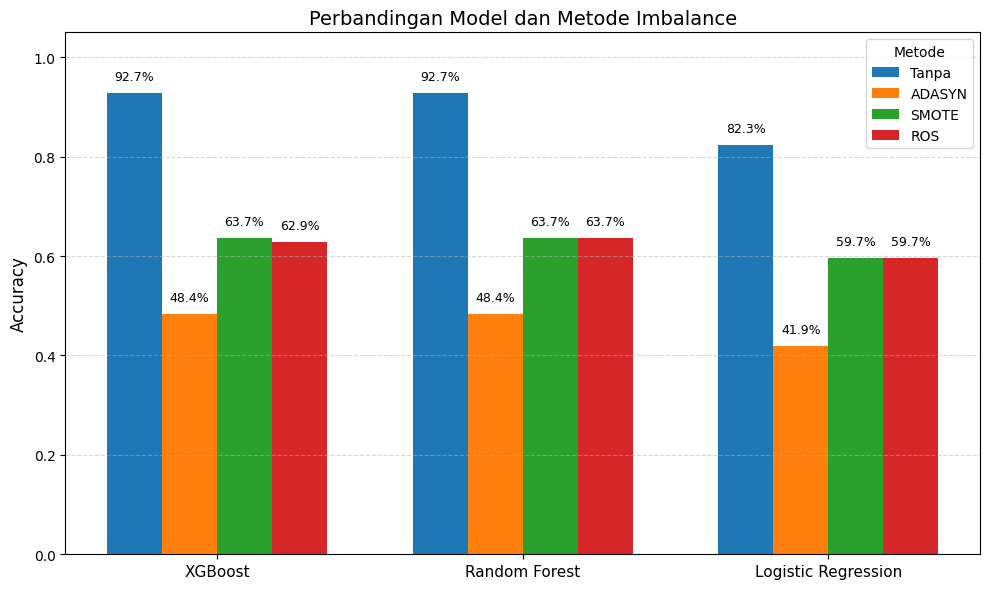

In [109]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# =========================
# HITUNG AKURASI OTOMATIS
# =========================

models = ['XGBoost', 'Random Forest', 'Logistic Regression']

tanpa = [
    accuracy_score(y_test, y_pred_no),
    accuracy_score(y_test, y_pred_rf_no),
    accuracy_score(y_test, y_pred_lr)
]

adasyn = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_rf_adasyn),
    accuracy_score(y_test, y_pred_lr_adasyn)
]

smote = [
    accuracy_score(y_test, y_pred_smote),
    accuracy_score(y_test, y_pred_rf_smote),
    accuracy_score(y_test, y_pred_lr_smote)
]

ros = [
    accuracy_score(y_test, y_pred_ros),
    accuracy_score(y_test, y_pred_rf_ros),
    accuracy_score(y_test, y_pred_lr_ros)
]

# =========================
# PLOT
# =========================

x = np.arange(len(models))
width = 0.18

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - 1.5*width, tanpa, width, label='Tanpa')
bars2 = plt.bar(x - 0.5*width, adasyn, width, label='ADASYN')
bars3 = plt.bar(x + 0.5*width, smote, width, label='SMOTE')
bars4 = plt.bar(x + 1.5*width, ros, width, label='ROS')

# =========================
# LABEL PERSENTASE
# =========================

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f'{height*100:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

# =========================
# TAMPILAN
# =========================

plt.xticks(x, models, fontsize=11)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Perbandingan Model dan Metode Imbalance", fontsize=14)

plt.legend(title="Metode")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()